# Benchmarking sample representation methods on COVID-19 PBMCs


## The problem

We'll work with the [COMBAT dataset](https://www.kaggle.com/datasets/shitovvladimir/a-blood-atlas-of-covid-19-combat-preprocessed) {cite}`ahern2022blood`: ~140 PBMC samples from COVID-19 patients and healthy donors, processed across multiple hospitals (`Source` / `Institute`) and sequencing pools (`Pool_ID`), with clinical outcomes spanning healthy → mild → severe → critical → death within 28 days.

We want a sample-level representation that lets us answer two questions in one go:

1. **Does it capture the clinical signal?** Patients with worse outcomes should sit closer to each other than to healthy donors.
2. **Is it robust to technical variation?** Whether a sample came from hospital A or hospital B, or pool 1 vs pool 2, should be (almost) invisible — those are technical artefacts, not biology.

These two requirements are in tension. A representation that scores high on (1) by accidentally encoding which institute ran the experiment is no use. In this notebook we'll run several `patpy` methods, evaluate each against both criteria, and end with a single comparison table.


## What we'll do

Starting from the simplest representation (pseudobulk) and working up to deep, batch-aware methods (MrVI, scPoli), we'll:

1. Set up COMBAT and extract sample-level metadata.
2. Run each method through the same `patpy` lifecycle (`prepare_anndata` → `calculate_distance_matrix` → `plot_embedding` → `evaluate_representation`).
3. Score every method against the same set of covariates with kNN classification / regression and with a trajectory-correlation score on `Outcome`.
4. Compare side-by-side in one table, then briefly run the same workflow on a different dataset (HLCA) to show it ports.

### Installation

Most of what we use ships with the base install (`pip install patpy`). The deep methods need extras (and ideally a CUDA GPU):

```bash
pip install patpy[pilot,mrvi,scpoli,diffusionemd]
pip install mofapy2  # MOFA isn't behind an extra yet
```

GloScope's R version has its own setup; see the dedicated tutorial linked at the end. A reproducible conda env is at [`envs/benchmark_tutorial.yaml`](https://github.com/lueckenlab/patpy/blob/main/envs/benchmark_tutorial.yaml).


## Import packages

In [ ]:
import ehrapy as ep
import pandas as pd
import scanpy as sc
import patpy
import seaborn as sns
from plottable import ColumnDefinition, Table
from plottable.cmap import normed_cmap
from plottable.plots import bar
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

/home/icb/vladimir.shitov/software/miniconda3/envs/rapids_singlecell/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/home/icb/vladimir.shitov/software/miniconda3/envs/rapids_singlecell/lib/python3.11/site-packages/distributed/diagnostics/rmm.py:8: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
  import rmm
/home/icb/vladimir.shitov/software/miniconda3/envs/rapids_singlecell/lib/python3.11/site-packages/rmm/__init__.py:15: FutureWarning: The cuda.cuda module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.driver module instea

In [ ]:
patpy.__version__

'0.15.2'

## Read the data

We'll start with the [COMBAT dataset](https://www.kaggle.com/datasets/shitovvladimir/a-blood-atlas-of-covid-19-combat-preprocessed). {cite}`ahern2022blood` This dataset contains 783k peripheral blood mononuclear cells from 140 samples of COVID-19 patients and healthy donors. A preprocessed version of COMBAT dataset can be easily loaded with `patpy`:

In [ ]:
adata = patpy.datasets.combat()
adata

AnnData object with n_obs × n_vars = 783677 × 3000
    obs: 'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'Annotation_major_subset', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'TCR_chain_composition', 'TCR_clone_ID', 'TCR_clone_count', 'TCR_clone_proportion', 'TCR_contains_unproductive', 'TCR_doublet', 'TCR_chain_TRA', 'TCR_v_gene_TRA', 'TCR_d_gene_TRA', 'TCR_j_gene_TRA', 'TCR_c_gene_TRA', 'TCR_productive_TRA', 'TCR_cdr3_TRA', 'TCR_umis_TRA', 'TCR_chain_TRA2', 'TCR_v_gene_TRA2', 'TCR_d_gene_TRA2', 'TCR_j_gene_TRA2', 'TCR_c_gene_TRA2', 'TCR_productive_TRA2', 'TCR_cdr3_TRA2', 'TCR_umis_TRA2', 'TCR_chain_TRB', 'TCR_v_gene_TRB', 'TCR_d_gene_TRB', 'TCR_j_gene_TRB', 'TCR_c_gene_TRB', 'TCR_productive_TRB', 'TCR_chain_TRB2', 'TCR_v_gene_TRB2', 'TCR_d_gene_TRB2', 'TCR_j_gene_TRB2', 'TCR_c_gene_TRB2', 'TCR_productive_TRB2', 'TCR_cdr3_TRB2', 'TCR_umis_TRB2', 'BCR_umis_HC', 'BCR_contig_qc_HC

Set the `PATPY_NB_TEST` environment variable to a non-empty value before launching the kernel to run a quick smoke-test on a tiny subset (15 donors, 10% of cells per donor with a floor of 10). Otherwise the notebook runs on the full ~783k cells / ~140 donors.


In [ ]:
import os
import numpy as np

if os.environ.get("PATPY_NB_TEST"):
    rng = np.random.default_rng(67)
    sample_ids = adata.obs["scRNASeq_sample_ID"].unique()
    test_donors = rng.choice(sample_ids, size=min(15, len(sample_ids)), replace=False)
    adata = adata[adata.obs["scRNASeq_sample_ID"].isin(test_donors)].copy()
    adata = patpy.pp.subsample(
        adata,
        obs_category_col="scRNASeq_sample_ID",
        min_samples_per_category=10,
        fraction=0.1,
    )
    print(f"PATPY_NB_TEST: subsampled to {adata.n_obs} cells across "
          f"{adata.obs['scRNASeq_sample_ID'].nunique()} donors")


Set columns containing sample IDs, cell types and `.obs` columns containing sample-level metadata:

In [ ]:
sample_key = "scRNASeq_sample_ID"
cell_type_key = "cell_type"
sample_level_columns = ["Source", "Outcome", "Death28", "Institute", "Pool_ID", "Age"]


Currently, there is no such columns as "cell_type" in the data. But cell types are stored in the `Annotation_major_subset` column. Let's rename it to `cell_type` for better readability.

In [ ]:
adata.obs.rename(columns={"Annotation_major_subset": cell_type_key}, inplace=True)

## Store metadata and calculate QC metrics

We want to evaluate how different sample representation methods preserve the useful information and whether they are affected by batch effects. To do that, we need to extract sample-level metadata and aggregate cell-level QC metrics. All of it can be conveniently done with `patpy` preprocessing module:

In [ ]:
metadata = patpy.pp.extract_metadata(adata, sample_key, sample_level_columns)
metadata

,Source,Outcome,Death28,Institute,Pool_ID
scRNASeq_sample_ID,,,,,
S00109-Ja001E-PBCa,COVID_SEV,2.0,0,Oxford,gPlexA
S00112-Ja003E-PBCa,COVID_MILD,5.0,0,Oxford,gPlexA
S00005-Ja005E-PBCa,COVID_CRIT,2.0,0,Oxford,gPlexA
S00061-Ja003E-PBCa,COVID_SEV,4.0,0,Oxford,gPlexA
S00056-Ja003E-PBCa,COVID_SEV,3.0,0,Oxford,gPlexA
...,...,...,...,...,...
S00065-Ja003E-PBCa,COVID_CRIT,2.0,0,Oxford,gPlexK
S00048-Ja003E-PBCa,COVID_SEV,4.0,0,Oxford,gPlexK
G05112-Ja005E-PBCa,COVID_HCW_MILD,6.0,0,Oxford,gPlexK


This function will aggregate cell level QC metrics per sample. By default, median aggregation is used. Make sure the columns you want to aggregate are in `adata.obs`! Here, we'll use number of genes per cell, percentage of mitochondrial genes, and doublet score:

In [ ]:
cell_qc_metadata = patpy.pp.calculate_cell_qc_metrics(
    adata, sample_key=sample_key, cell_qc_vars=["QC_ngenes", "QC_pct_mitochondrial", "QC_scrub_doublet_scores"]
)
cell_qc_metadata

,median_QC_ngenes,median_QC_pct_mitochondrial,median_QC_scrub_doublet_scores
scRNASeq_sample_ID,,,
G05061-Ja005E-PBCa,1107.0,3.011159,0.050648
G05064-Ja005E-PBCa,975.0,1.332430,0.060894
G05073-Ja005E-PBCa,1141.0,2.422559,0.044530
G05077-Ja005E-PBCa,1125.0,2.946723,0.048490
G05078-Ja005E-PBCa,999.0,2.825308,0.052783
...,...,...,...
U00607-Ua005E-PBUa,1827.0,2.982509,0.043323
U00613-Ua005E-PBUa,1251.5,2.053083,0.036956
U00617-Ua005E-PBUa,1410.5,3.886215,0.057906


In [ ]:
n_genes_metadata = patpy.pp.calculate_n_cells_per_sample(adata, sample_key)
n_genes_metadata

,n_cells
scRNASeq_sample_ID,
S00052-Ja005E-PBCa,13918
H00054-Ha001E-PBGa,10938
H00067-Ha001E-PBGa,10781
N00023-Ja001E-PBGa,10484
H00053-Ha001E-PBGa,10458
...,...
U00607-Ua005E-PBUa,1021
U00613-Ua005E-PBUa,970
U00701-Ua005E-PBUa,872


Additionally, let's compute cell type proportions to see if they impact sample representations:

In [ ]:
composition_metadata = patpy.pp.calculate_compositional_metrics(adata, sample_key, [cell_type_key], normalize_to=100)
composition_metadata

cell_type,cell_type_B,cell_type_CD4,cell_type_CD8,cell_type_DC,cell_type_DN,cell_type_DP,cell_type_GDT,cell_type_HSC,cell_type_MAIT,cell_type_Mast,cell_type_NK,cell_type_PB,cell_type_PLT,cell_type_RET,cell_type_cMono,cell_type_iNKT,cell_type_ncMono
scRNASeq_sample_ID,,,,,,,,,,,,,,,,,
G05061-Ja005E-PBCa,6.324900,33.921438,12.366844,1.597870,0.532623,0.499334,0.898802,0.066578,4.677097,0.000000,18.159121,0.316245,0.166445,0.016644,15.812250,0.033289,4.610519
G05064-Ja005E-PBCa,3.405158,47.147482,16.400581,1.819806,1.228090,0.725689,2.188233,0.022329,1.317405,0.000000,7.457854,0.446578,0.000000,0.000000,14.357486,0.000000,3.483309
G05073-Ja005E-PBCa,5.194338,45.609405,16.278791,1.487524,1.247601,0.839731,4.654511,0.011996,2.195298,0.011996,3.730806,0.203935,0.047985,0.000000,13.963532,0.083973,4.438580
G05077-Ja005E-PBCa,5.846211,29.231056,14.596909,1.377770,0.446844,1.340532,0.465463,0.167567,0.800596,0.018619,22.844908,1.079873,0.074474,0.018619,18.004096,0.055856,3.630609
G05078-Ja005E-PBCa,1.366381,39.000106,15.591569,2.340854,0.762631,0.730855,2.648025,0.211842,1.737104,0.021184,10.666243,0.148289,0.021184,0.000000,19.521237,0.497829,4.734668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
U00607-Ua005E-PBUa,3.623898,10.577865,1.273262,4.701273,0.097943,0.195886,0.195886,0.685602,0.097943,0.000000,5.876592,1.175318,1.958864,0.097943,37.904016,0.000000,31.537708
U00613-Ua005E-PBUa,7.835052,26.391753,16.907216,0.721649,0.412371,0.309278,1.649485,0.000000,0.103093,0.000000,5.154639,1.237113,0.206186,0.000000,37.938144,0.000000,1.134021
U00617-Ua005E-PBUa,2.977233,41.418564,16.462347,0.437828,0.525394,0.262697,0.262697,0.963222,0.087566,0.000000,7.530648,17.513135,0.788091,0.087566,9.719790,0.000000,0.963222


Merge metadata tables into one. Always make sure that sample order is the same!

In [ ]:
metadata = pd.concat(
    [
        metadata,
        cell_qc_metadata.loc[metadata.index],
        n_genes_metadata.loc[metadata.index],
        composition_metadata.loc[metadata.index],
    ],
    axis=1,
)

In [ ]:
metadata.shape

(138, 26)

## Two questions, one notebook

Before running any methods, let's pin down what "good" looks like. We split the metadata columns into two buckets:

| Type | Covariates | What a good representation does |
| --- | --- | --- |
| Clinical | `Outcome`, `Death28`, `Source` | High kNN score — captures it |
| Technical | `Institute`, `Pool_ID`, `n_cells`, `median_QC_ngenes` | Low kNN score — ignores it |

We'll evaluate every representation against this same set, plus a trajectory-correlation score that asks how well diffusion pseudotime over the representation tracks `Outcome` (rooted at the youngest healthy donor). The final table at the bottom of the notebook scores all methods on all covariates side-by-side.


# Quality control

To reduce noise in the representations, we need to remove samples with too few cells:

In [ ]:
adata.obs[sample_key].value_counts()

scRNASeq_sample_ID
S00052-Ja005E-PBCa    13918
H00054-Ha001E-PBGa    10938
H00067-Ha001E-PBGa    10781
N00023-Ja001E-PBGa    10484
H00053-Ha001E-PBGa    10458
                      ...  
U00607-Ua005E-PBUa     1021
U00613-Ua005E-PBUa      970
U00701-Ua005E-PBUa      872
U00601-Ua005E-PBUa      619
U00504-Ua005E-PBUa      161
Name: count, Length: 138, dtype: int64

In [ ]:
adata = patpy.pp.filter_small_samples(adata, sample_key=sample_key, sample_size_threshold=200)

1 samples removed: U00504-Ua005E-PBUa


Some methods (GroupedPseudobulk, MOFA) iterate per cell type per sample, so they fail when a cell type has zero cells in some samples. Trim those out:


In [ ]:
adata = patpy.pp.filter_small_cell_groups(
    adata,
    sample_key=sample_key,
    cell_group_key=cell_type_key,
    cluster_size_threshold=5,
)


If necessary, we can also remove cell types with too few cells in at least one sample:

`adata = patpy.pp.filter_small_cell_groups(adata, sample_key=sample_key, cell_group_key=cell_type_key, cluster_size_threshold=10)`

Some methods require this filtering step prior to building representation. In this notebook, we'll focus on simpler methods that can be used with only sample filtering.

## Method 1 — Pseudobulk


### Why this method?

Pseudobulk is the simplest sample representation: average every cell of a sample into a single vector. It's a strong baseline because most signals visible at the tissue level survive averaging. The catch is the choice of cell-level features — raw expression, PCA, or an integrated latent space (scVI, scANVI, scPoli) all give different answers. Below we try three layers and look at what changes.


In [ ]:
# Set up the sample representation method
pseudobulk_gene_expression = patpy.tl.Pseudobulk(
    sample_key=sample_key,
    cell_group_key=cell_type_key,  
    layer="X"  # Use adata.X that currently contains log-normalised expression
)
pseudobulk_gene_expression.prepare_anndata(adata)  # Prepare data
pseudobulk_gene_expression.calculate_distance_matrix(force=True);  # Compute sample representation

But which cell representations should we use? In the literature, there is an inconsistency: some people prefer using gene expression, while other use latent features of the cells produced by dimensionality reduction methods. We can quickly test different cell representations by changing `layer` parameter:

In [ ]:
pseudobulk_pca = patpy.tl.Pseudobulk(sample_key=sample_key, cell_group_key=cell_type_key, layer="X_pca")
pseudobulk_pca.prepare_anndata(adata)
pseudobulk_pca.calculate_distance_matrix(force=True);

In [ ]:
pseudobulk_scvi = patpy.tl.Pseudobulk(sample_key=sample_key, cell_group_key=cell_type_key, layer="X_scVI_batch")
pseudobulk_scvi.prepare_anndata(adata)
pseudobulk_scvi.calculate_distance_matrix(force=True);

Representations can now easily be visualised:

In [ ]:
pseudobulk_gene_expression.embeddings

{'UMAP': array([[ 6.411637 , 10.230247 ],
        [ 9.097273 , 12.043398 ],
        [ 9.339384 , 12.795696 ],
        [ 6.0200143,  9.995653 ],
        [ 9.183574 ,  9.938261 ],
        [10.528054 ,  9.700788 ],
        [10.615247 , 12.061244 ],
        [ 8.845466 , 12.571351 ],
        [10.208051 , 12.376021 ],
        [10.80369  , 10.22028  ],
        [ 6.021367 , 10.386376 ],
        [10.577501 ,  9.9936495],
        [ 8.608129 , 12.85596  ],
        [ 7.849205 ,  9.865853 ],
        [ 8.679156 , 11.5301895],
        [ 8.277834 , 12.408462 ],
        [ 8.612643 ,  9.956364 ],
        [10.006337 ,  8.89309  ],
        [ 9.772537 , 12.672723 ],
        [11.496751 , 11.510889 ],
        [ 8.878105 ,  9.541963 ],
        [ 6.745065 , 11.517748 ],
        [ 8.902437 , 12.425303 ],
        [ 9.329438 , 12.54178  ],
        [ 9.562843 , 12.243174 ],
        [10.004125 , 12.720798 ],
        [10.384387 , 10.161545 ],
        [ 6.2027807,  9.82843  ],
        [ 7.2035913, 10.636264 ],
      

In [ ]:
pseudobulk_pca.embeddings

{'UMAP': array([[ 6.411637 , 10.230247 ],
        [ 9.097273 , 12.043398 ],
        [ 9.339384 , 12.795696 ],
        [ 6.0200143,  9.995653 ],
        [ 9.183574 ,  9.938261 ],
        [10.528054 ,  9.700788 ],
        [10.615247 , 12.061244 ],
        [ 8.845466 , 12.571351 ],
        [10.208051 , 12.376021 ],
        [10.80369  , 10.22028  ],
        [ 6.021367 , 10.386376 ],
        [10.577501 ,  9.9936495],
        [ 8.608129 , 12.85596  ],
        [ 7.849205 ,  9.865853 ],
        [ 8.679156 , 11.5301895],
        [ 8.277834 , 12.408462 ],
        [ 8.612643 ,  9.956364 ],
        [10.006337 ,  8.89309  ],
        [ 9.772537 , 12.672723 ],
        [11.496751 , 11.510889 ],
        [ 8.878105 ,  9.541963 ],
        [ 6.745065 , 11.517748 ],
        [ 8.902437 , 12.425303 ],
        [ 9.329438 , 12.54178  ],
        [ 9.562843 , 12.243174 ],
        [10.004125 , 12.720798 ],
        [10.384387 , 10.161545 ],
        [ 6.2027807,  9.82843  ],
        [ 7.2035913, 10.636264 ],
      

array([<Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>], dtype=object)

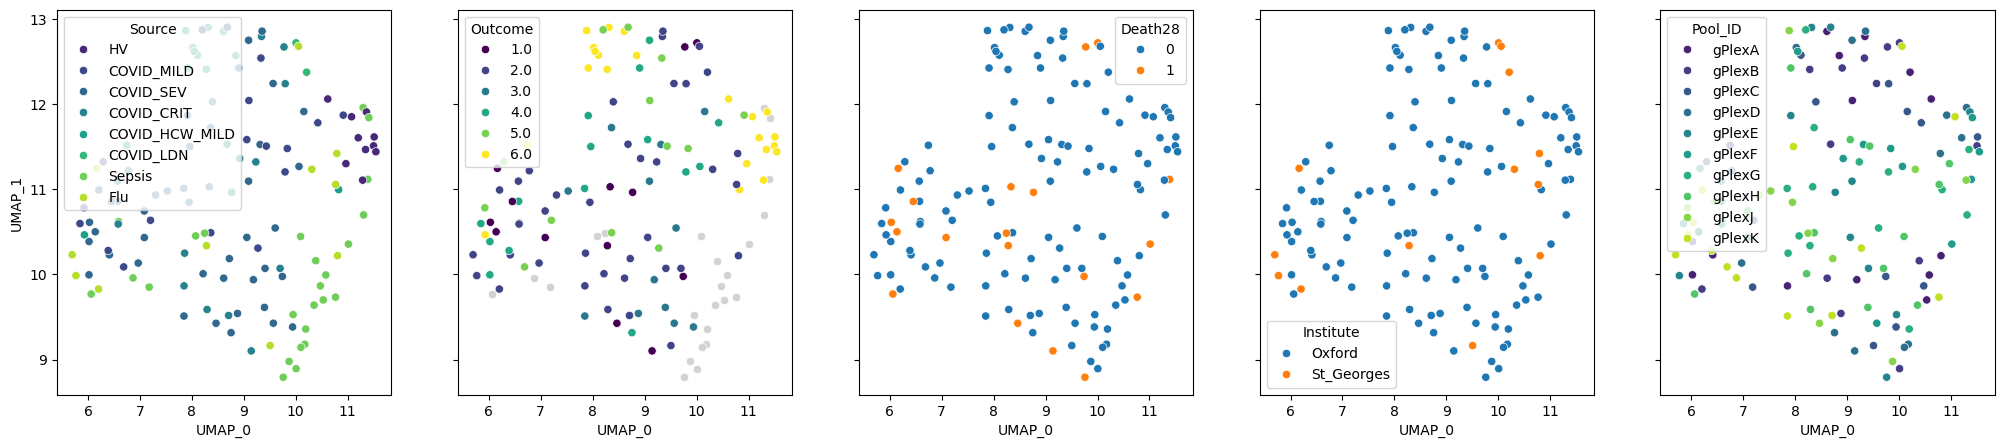

In [ ]:
pseudobulk_gene_expression.plot_embedding("UMAP", sample_level_columns)

array([<Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>], dtype=object)

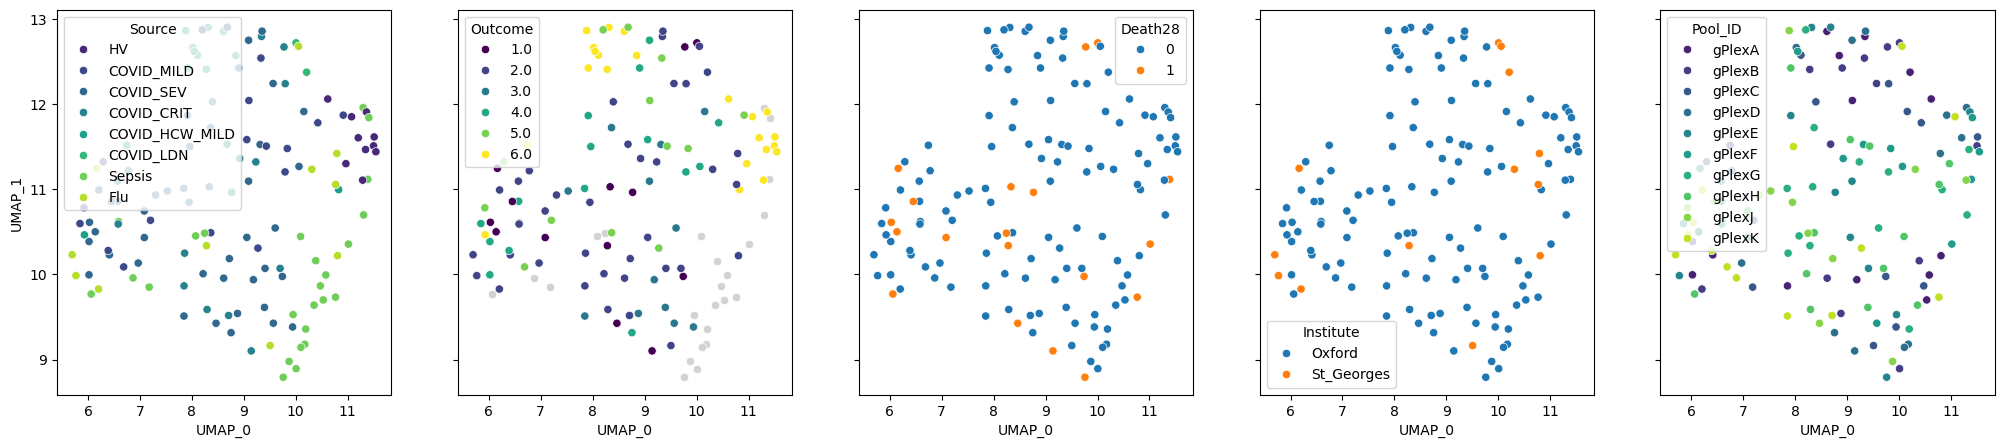

In [ ]:
pseudobulk_pca.plot_embedding("UMAP", sample_level_columns)

array([<Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>], dtype=object)

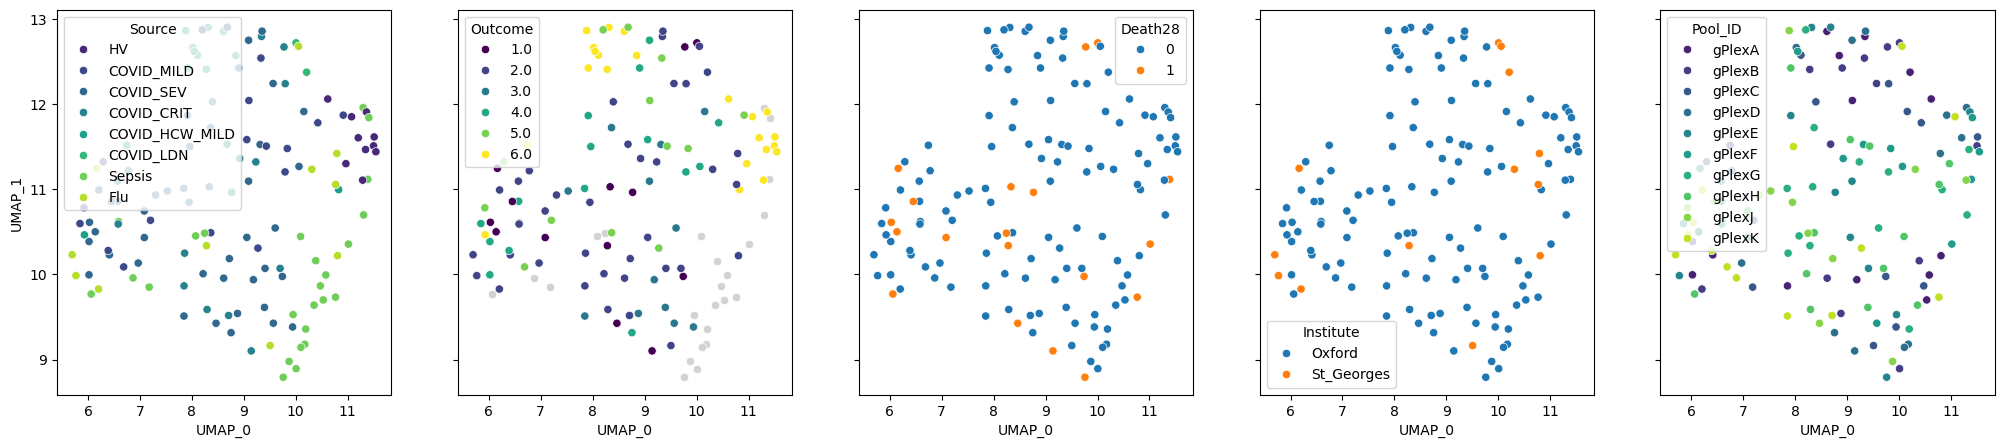

In [ ]:
pseudobulk_scvi.plot_embedding("UMAP", sample_level_columns)

### Evaluate how well a covariate is represented

Let's try to classify "Outcome" based on the nearest neighbors for each sample in the representation:

In [ ]:
pseudobulk_pca.evaluate_representation(target="Outcome", method="knn", n_neighbors=5, task="classification")

{'score': 0.13977126662840952,
 'metric': 'f1_macro_calibrated',
 'n_unique': 6,
 'n_observations': 113,
 'method': 'knn'}

It doesn't work too good. Now we can try to solve the ranking problem for the same covariate. It will train regressor and use a different metric for evaluation:

In [ ]:
pseudobulk_pca.evaluate_representation(target="Outcome", method="knn", n_neighbors=5, task="ranking")

{'score': 0.6103813851943187,
 'metric': 'spearman_r',
 'n_unique': 6,
 'n_observations': 113,
 'method': 'knn'}

Now let's see how well Pool is represented. This is a technical covariate so we don't want score to be high:

In [ ]:
pseudobulk_pca.evaluate_representation(target="Pool_ID", method="knn", n_neighbors=5, task="classification")

{'score': 0.13579292359838518,
 'metric': 'f1_macro_calibrated',
 'n_unique': 10,
 'n_observations': 138,
 'method': 'knn'}

Save the distances to adata to use later

In [ ]:
adata.uns["pseudobulk_distances"] = pseudobulk_pca.calculate_distance_matrix()
adata.uns["pseudobulk_samples"] = pseudobulk_pca.samples
adata.uns["pseudobulk_UMAP"] = pseudobulk_pca.embeddings["UMAP"]

## Method 2 — CellGroupComposition


This representation is based on cell type composition differences. It is calculated as a difference between cell type proportions in each sample.

In [ ]:
composition = patpy.tl.CellGroupComposition(
    sample_key=sample_key, cell_group_key=cell_type_key,
)
composition.prepare_anndata(adata)
composition_distances = composition.calculate_distance_matrix(force=True)


array([<Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>], dtype=object)

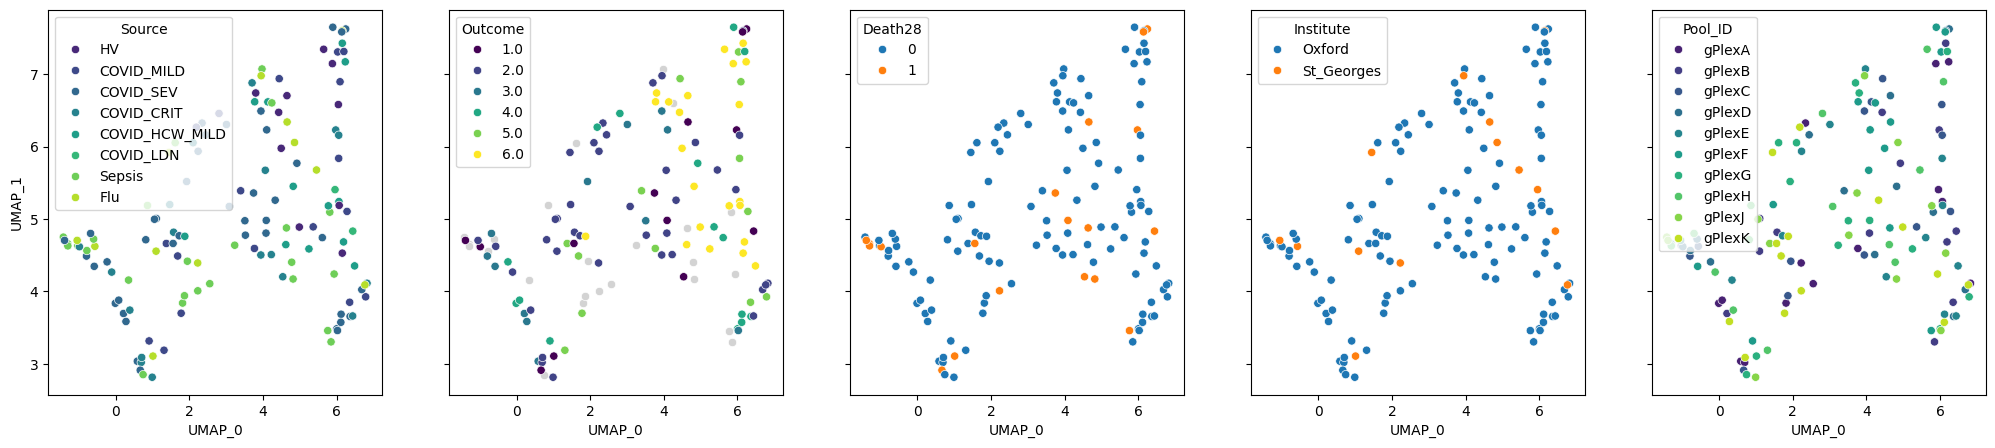

In [ ]:
composition.plot_embedding(method="UMAP", metadata_cols=sample_level_columns)

We can also visualise cell type proportions for each sample:

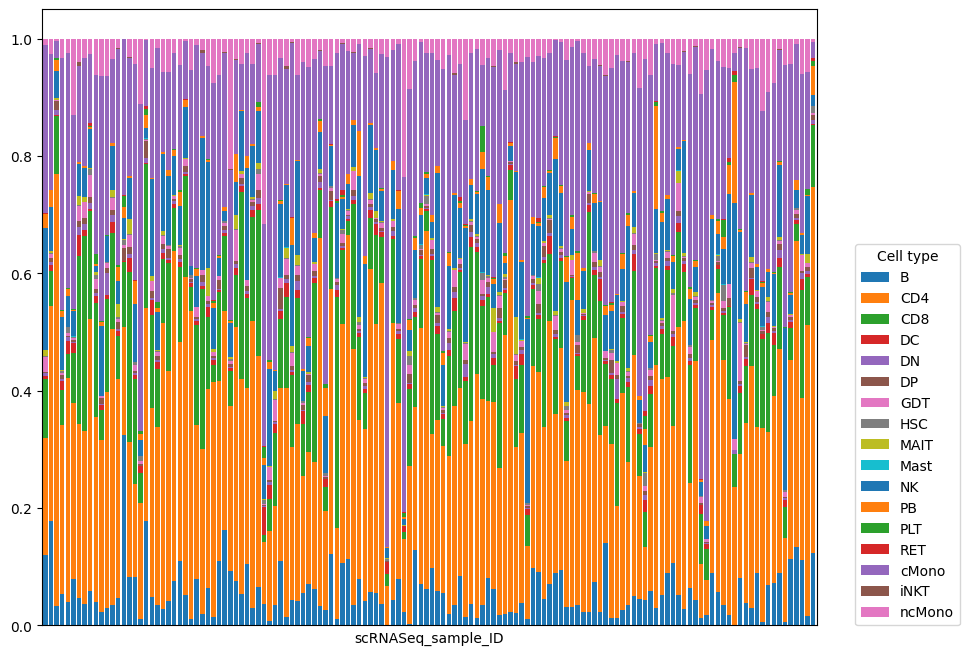

In [ ]:
composition.sample_representation.plot(kind="bar", stacked=True, figsize=(10, 8), width=0.8)
plt.xticks([])
plt.legend(loc=(1.05, 0), title="Cell type");

We can see that cell type composition reflects patient outcome worse than pseudobulk:

In [ ]:
composition.evaluate_representation(target="Outcome", method="knn", n_neighbors=5, task="ranking")

{'score': 0.4739538892493282,
 'metric': 'spearman_r',
 'n_unique': 6,
 'n_observations': 113,
 'method': 'knn'}

In [ ]:
adata.uns["composition_distances"] = composition_distances
adata.uns["composition_samples"] = composition.samples

## Method 3 — PILOT


[PILOT](https://pubmed.ncbi.nlm.nih.gov/38177382/) is an Optimal Transport-based tool, which calculates distances between samples based on cell type proportion differences taking into account cell type similarities. Note that to run it, you need to install the dependencies additionally:

`pip install patpy[pilot]`

In [ ]:
pilot = patpy.tl.PILOT(
    sample_key=sample_key,
    cell_group_key=cell_type_key,
    layer="X_scVI_batch",
    sample_state_col="Outcome",  # not used for distance calculation
)

In [ ]:
pilot.prepare_anndata(adata)

In [ ]:
pilot.calculate_distance_matrix()

array([[0.        , 0.14451829, 0.42457524, ..., 0.10953257, 0.21343671,
        0.36804272],
       [0.14451829, 0.        , 0.32280757, ..., 0.10045083, 0.13157015,
        0.25766875],
       [0.42457524, 0.32280757, 0.        , ..., 0.36857701, 0.23438838,
        0.08670158],
       ...,
       [0.10953257, 0.10045083, 0.36857701, ..., 0.        , 0.17271665,
        0.31134621],
       [0.21343671, 0.13157015, 0.23438838, ..., 0.17271665, 0.        ,
        0.21202688],
       [0.36804272, 0.25766875, 0.08670158, ..., 0.31134621, 0.21202688,
        0.        ]])

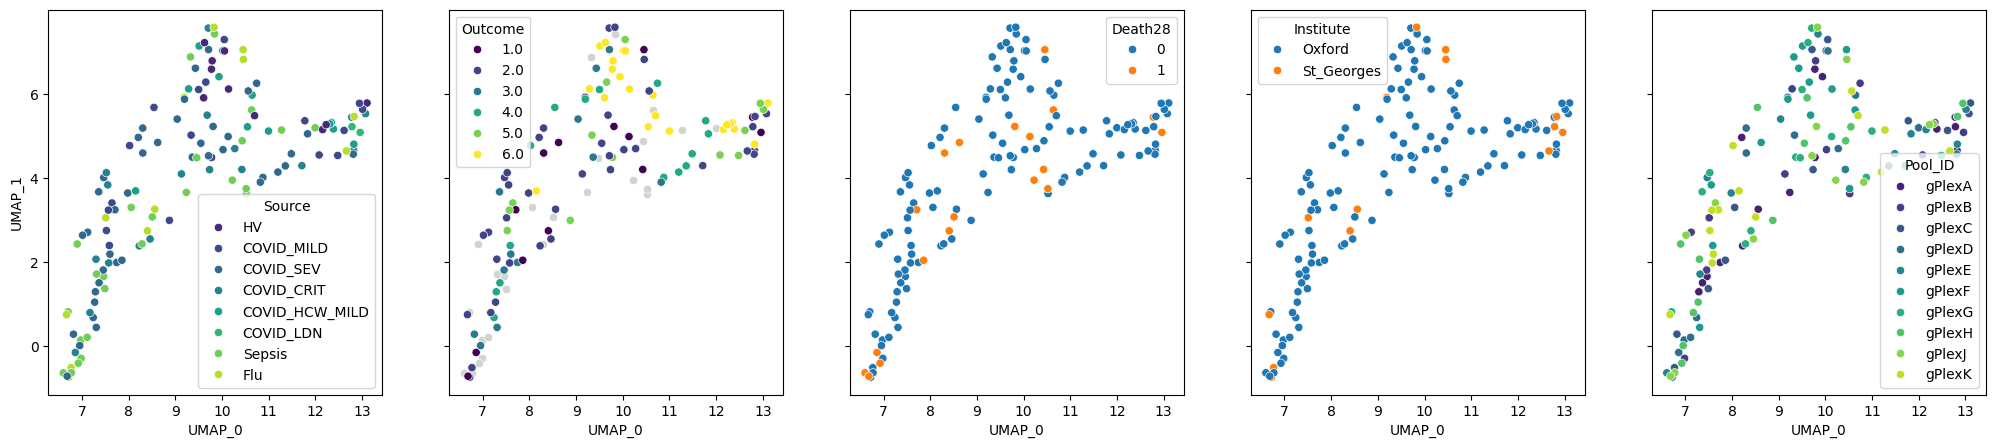

In [ ]:
pilot.plot_embedding(method="UMAP", metadata_cols=sample_level_columns);

In [ ]:
adata.uns["pilot_distances"] = pilot.calculate_distance_matrix()
adata.uns["pilot_samples"] = pilot.samples
adata.uns["pilot_UMAP"] = pilot.embeddings["UMAP"]

Let's check the covariates:

In [ ]:
pilot.evaluate_representation(target="Outcome", method="knn", n_neighbors=5, task="ranking")

{'score': 0.48835133146990367,
 'metric': 'spearman_r',
 'n_unique': 6,
 'n_observations': 113,
 'method': 'knn'}

In [ ]:
pilot.evaluate_representation(target="Pool_ID", method="knn", n_neighbors=5, task="classification")

{'score': 0.01832203003010072,
 'metric': 'f1_macro_calibrated',
 'n_unique': 10,
 'n_observations': 138,
 'method': 'knn'}

Outcome is represented a bit worse, but Pool ID almost doesn't affect the representation

## Method 4 — GroupedPseudobulk


### Why this method?

GroupedPseudobulk is one step richer than Pseudobulk: instead of one vector per sample, you get one vector *per cell type per sample*, then concatenate them. If your biological signal lives in *which* cell types respond rather than the global average, this representation surfaces it.


In [ ]:
grouped_pseudobulk = patpy.tl.GroupedPseudobulk(
    sample_key=sample_key,
    cell_group_key=cell_type_key,
    layer="X_scVI_batch",
)
grouped_pseudobulk.prepare_anndata(adata)
grouped_pseudobulk.calculate_distance_matrix();


In [ ]:
grouped_pseudobulk.plot_embedding(method="UMAP", metadata_cols=sample_level_columns);


In [ ]:
adata.uns["grouped_pseudobulk_distances"] = grouped_pseudobulk.calculate_distance_matrix()
adata.uns["grouped_pseudobulk_samples"] = grouped_pseudobulk.samples
adata.uns["grouped_pseudobulk_UMAP"] = grouped_pseudobulk.embeddings["UMAP"]


## Method 5 — RandomVector (sanity baseline)


### Why this method?

RandomVector assigns each sample a vector of Gaussian noise. It exists as a *floor* for the comparison table: any real method should beat random on the clinical covariates and should *not* beat random on the technical ones.


In [ ]:
random = patpy.tl.RandomVector(
    sample_key=sample_key,
    cell_group_key=cell_type_key,
)
random.prepare_anndata(adata)
random.calculate_distance_matrix();


In [ ]:
random.plot_embedding(method="UMAP", metadata_cols=sample_level_columns);


In [ ]:
adata.uns["random_distances"] = random.calculate_distance_matrix()
adata.uns["random_samples"] = random.samples
adata.uns["random_UMAP"] = random.embeddings["UMAP"]


## Method 6 — MOFA


### Why this method?

MOFA2 fits a multi-view factor model: each cell type becomes a view, and shared latent factors are inferred across views. The factors capture biological axes of variation that are coherent across cell types — useful when no single cell type tells the whole story.

Requires `pip install mofapy2` (no `[mofa]` extra in patpy yet).


In [ ]:
mofa = patpy.tl.MOFA(
    sample_key=sample_key,
    cell_group_key=cell_type_key,
    n_factors=10,
    aggregate_cell_types=True,
)
mofa.prepare_anndata(adata)
mofa.calculate_distance_matrix();


In [ ]:
mofa.plot_embedding(method="UMAP", metadata_cols=sample_level_columns);


In [ ]:
adata.uns["mofa_distances"] = mofa.calculate_distance_matrix()
adata.uns["mofa_samples"] = mofa.samples
adata.uns["mofa_UMAP"] = mofa.embeddings["UMAP"]


## Method 7 — MrVI


### Why this method?

MrVI is a deep generative model conditioned explicitly on `sample_key` (and optionally `batch_key`), so per-sample variation becomes a first-class part of the latent space rather than something to denoise away. Sample distances fall out of comparing per-sample representations directly.

Requires `pip install patpy[mrvi]` and ideally a CUDA GPU. Raw counts must be available in `adata.layers["counts"]`.


In [ ]:
mrvi = patpy.tl.MrVI(
    sample_key=sample_key,
    cell_group_key=cell_type_key,
    batch_key="Pool_ID",
    layer="X_raw_counts",  # MrVI needs raw counts
    max_epochs=100,
)
mrvi.prepare_anndata(adata)
mrvi.calculate_distance_matrix();


In [ ]:
mrvi.plot_embedding(method="UMAP", metadata_cols=sample_level_columns);


In [ ]:
adata.uns["mrvi_distances"] = mrvi.calculate_distance_matrix()
adata.uns["mrvi_samples"] = mrvi.samples
adata.uns["mrvi_UMAP"] = mrvi.embeddings["UMAP"]


# Compare representations

Let's write a small function to put all the sample representations into a single object. It will make sure that the order of samples is identical and cluster the patients

In [ ]:
def align_representations(adata, meta_adata, samples, methods):
    """
    Align representations of different methods to have the same order of samples.

    Additionally runs clustering with Leiden algorithm.
    """
    for method in methods:
        #     samples_to_take = np.isin(adata.uns[f"{method}_samples"], samples)
        representation_samples = adata.uns[f"{method}_samples"].tolist()
        samples_order = [representation_samples.index(sample) for sample in samples if sample in representation_samples]

        assert (adata.uns[f"{method}_samples"][samples_order] == samples).all(), "Order of samples is not correct"

        # meta_adata.obsm["umap"] = meta_adata.obsm[f"{method}_UMAP"]
        meta_adata.obsm[f"{method}_distances"] = adata.uns[f"{method}_distances"][samples_order][:, samples_order]

        ep.pp.neighbors(
            meta_adata, use_rep=f"{method}_distances", key_added=f"{method}_neighbors", metric="precomputed"
        )
        ep.tl.leiden(meta_adata, key_added=f"{method}_leiden", neighbors_key=f"{method}_neighbors")

    return meta_adata

In [ ]:
combat_methods = [
    "pseudobulk",
    "composition",
    "pilot",
    "grouped_pseudobulk",
    "random",
    "mofa",
    "mrvi",
]


In [ ]:
combat_samples = list(set(adata.uns[f"{method}_samples"]) for method in combat_methods)
combat_samples = list(set.intersection(*combat_samples))
len(combat_samples)

In [ ]:
metadata = metadata.loc[combat_samples]

In [ ]:
combat_meta_adata = ep.io.df_to_anndata(metadata)
combat_meta_adata = ep.pp.encode(combat_meta_adata, autodetect=True)
combat_meta_adata

! Features 'Outcome', 'Death28' were detected as categorical features stored numerically.Please verify and correct using `ep.ad.replace_feature_types` if necessary.
! Feature types were inferred and stored in adata.var[feature_type]. Please verify using `ep.ad.feature_type_overview` and adjust if necessary using `ep.ad.replace_feature_types`.


AnnData object with n_obs × n_vars = 138 × 43
    obs: 'Source', 'Institute', 'Pool_ID'
    var: 'feature_type', 'unencoded_var_names', 'encoding_mode'
    layers: 'original'

In [ ]:
combat_meta_adata = align_representations(
    adata=adata,
    meta_adata=combat_meta_adata,
    samples=combat_samples,
    methods=combat_methods,
)

## Evaluation 1 — kNN scores per covariate

For each (representation, covariate) pair, we run a k-nearest-neighbours classification or regression directly on the precomputed sample distances. Scores are normalised to `[0, 1]` and we *invert* the score for technical covariates so that 1 = good (representation ignores the technical artefact) in every column.


In [ ]:
benchmark_schema = {
    "technical": ["Institute", "Pool_ID", "n_cells", "median_QC_ngenes"],
    "clinical": ["Death28", "Outcome", "Source"],
}

cols_with_tasks = {
    "Institute": "classification",
    "Pool_ID": "classification",
    "n_cells": "regression",
    "median_QC_ngenes": "regression",
    "Death28": "classification",
    "Outcome": "ranking",
    "Source": "classification",
}

# One colour per method, used in every plot below so the same method has the
# same colour wherever it appears.
method_colors = {
    "pseudobulk": "#1f77b4",
    "composition": "#ff7f0e",
    "pilot": "#2ca02c",
    "grouped_pseudobulk": "#d62728",
    "random": "#7f7f7f",
    "mofa": "#9467bd",
    "mrvi": "#17becf",
}


In [ ]:
results = []

for method in combat_methods:
    for covariate_type in benchmark_schema:
        for col in benchmark_schema[covariate_type]:
            task = cols_with_tasks[col]
            try:
                result = patpy.tl.evaluate_representation(
                    distances=combat_meta_adata.obsm[f"{method}_distances"],
                    target=metadata[col],
                    method="knn",
                    task=task,
                    #             n_neighbors=5
                )
            except Exception as e:
                print("Method:", method)
                print("Col:", col)
                print("Task:", task)
                print(e)
                print()
                continue
            #             raise(e)
            result["representation"] = method
            result["covariate"] = col
            result["covariate_type"] = covariate_type

            if result["metric"] == "spearman_r":
                result["score"] = abs(result["score"])

            if covariate_type == "technical":
                result["score"] = 1 - result["score"]

            results.append(result)

Scores are ranged from 0 to 1

- For covariates that we defined as technical, 0 means that covariate strongly affects the representation, and 1 means that this covariate is randomly distributed across representation
- For biological and clinical covariates, 0 means that a covariate is not represented well (it is randomly distributed), while 1 means that similar patients have similar values of covariate 

In [ ]:
knn_results = pd.DataFrame(results)
knn_results.sort_values("score", ascending=False)

,score,metric,n_unique,n_observations,method,representation,covariate,covariate_type
0,1.000000,f1_macro_calibrated,2,138,knn,pseudobulk,Institute,technical
8,1.000000,f1_macro_calibrated,10,138,knn,composition,Pool_ID,technical
15,1.000000,f1_macro_calibrated,10,138,knn,pilot,Pool_ID,technical
14,1.000000,f1_macro_calibrated,2,138,knn,pilot,Institute,technical
7,0.928846,f1_macro_calibrated,2,138,knn,composition,Institute,technical
1,0.824655,f1_macro_calibrated,10,138,knn,pseudobulk,Pool_ID,technical
9,0.803490,spearman_r,138,138,knn,composition,n_cells,technical
16,0.792614,spearman_r,138,138,knn,pilot,n_cells,technical
10,0.752516,spearman_r,119,138,knn,composition,median_QC_ngenes,technical
17,0.656404,spearman_r,119,138,knn,pilot,median_QC_ngenes,technical


Text(0.5, 1.0, 'KNN-score')

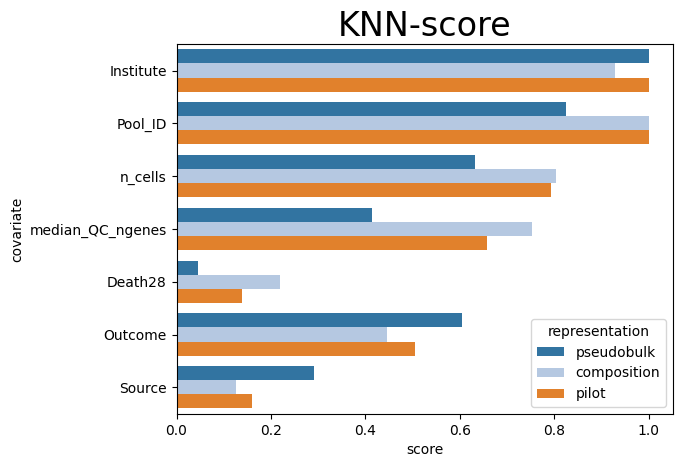

In [ ]:
# plt.figure(figsize=(10, 20))
sns.barplot(data=knn_results, y="covariate", x="score", orient="h", hue="representation", palette=method_colors)
plt.xlim(0, 1.05)
plt.title("KNN-score", fontsize=24)

## Evaluation 2 — trajectory preservation

kNN scores are local — they ask whether each sample's neighbours share the same covariate value. They don't tell us whether the *order* of severity is preserved: do healthy donors sit on one side, deceased patients on the other, and milder cases in between?

We answer that with diffusion pseudotime, rooted at a healthy donor: a good representation should produce a pseudotime that correlates with `Outcome` (higher = worse outcome). The Spearman correlation per representation is the score we add to the comparison table.


In [ ]:
# Trajectory root: the donor closest to the healthy end of the COMBAT severity scale.
# In COMBAT, Outcome is coded so 6 = healthy / mild HCW and 1 = critical, so we sort
# by Outcome descending. Among the healthiest donors, we break ties on Age (youngest).
# This is robust to test-mode subsampling that may drop all Source=='HV' samples.
candidates = metadata.dropna(subset=["Outcome", "Age"])
root_sample = candidates.sort_values(["Outcome", "Age"], ascending=[False, True]).index[0]
print(
    f"Trajectory root: {root_sample} "
    f"(Outcome={metadata.loc[root_sample, 'Outcome']:.0f}, "
    f"Age={metadata.loc[root_sample, 'Age']:.0f}, "
    f"Source={metadata.loc[root_sample, 'Source']})"
)


In [ ]:
trajectory_results = patpy.tl.trajectory_correlation(
    meta_adata=combat_meta_adata,
    root_sample=root_sample,
    trajectory_variable="Outcome",
    representations=combat_methods,
    inverse_trajectory=True,  # COMBAT codes 6 = healthy, 1 = critical
)
trajectory_results


In [ ]:
knn_results_wide = knn_results.pivot(index="representation", columns="covariate", values="score")

# Add trajectory preservation score early so it can feed into col_defs below
knn_results_wide["trajectory"] = (
    trajectory_results.loc[knn_results_wide.index, "correlation"].abs()
)

# Order the columns as in benchmark schema
cols_order = ["total", "trajectory"]

for covariate_type in benchmark_schema:
    cols_order.extend(benchmark_schema[covariate_type])
    cols_order.append(covariate_type)

cmap = LinearSegmentedColormap.from_list(
    name="bugw", colors=["#FF9693", "#f2fbd2", "#c9ecb4", "#93d3ab", "#35b0ab"], N=256
)

col_defs = []

col_defs.append(
    ColumnDefinition(
        "total",
        width=0.7,
        plot_fn=bar,
        plot_kw={
            "cmap": cmap,
            "plot_bg_bar": True,
            "annotate": True,
            "height": 0.5,
            "lw": 0.5,
            "formatter": lambda x: round(x, 2),
        },
    )
)

col_defs.append(
    ColumnDefinition(
        "trajectory",
        width=0.55,
        formatter=lambda x: round(x, 2),
        textprops={"ha": "center", "bbox": {"boxstyle": "circle", "pad": 0.35}},
        cmap=normed_cmap(knn_results_wide["trajectory"].dropna(), cmap=matplotlib.cm.PiYG, num_stds=2.5),
    )
)

for covariate_type in benchmark_schema:
    type_cols = benchmark_schema[covariate_type]

    for col in type_cols:
        col_def = ColumnDefinition(
            name=col,
            width=0.75,
            formatter=lambda x: round(x, 2),
            textprops={
                "ha": "center",
                "bbox": {"boxstyle": "circle", "pad": 0.35},
            },
            cmap=normed_cmap(knn_results["score"], cmap=matplotlib.cm.PiYG, num_stds=2.5),
            group=covariate_type,
        )

        col_defs.append(col_def)

    knn_results_wide[covariate_type] = knn_results_wide[type_cols].mean(axis=1)
    col_defs.append(
        ColumnDefinition(
            covariate_type,
            width=0.7,
            plot_fn=bar,
            plot_kw={
                "cmap": cmap,
                "plot_bg_bar": True,
                "annotate": True,
                "height": 0.5,
                "lw": 0.5,
                "formatter": lambda x: round(x, 2),
            },
        )
    )


#     col_defs.append(type_cols)
clin_weight = 2 / 3

knn_results_wide["total"] = (
    clin_weight * knn_results_wide["clinical"] + (1 - clin_weight) * knn_results_wide["technical"]
)


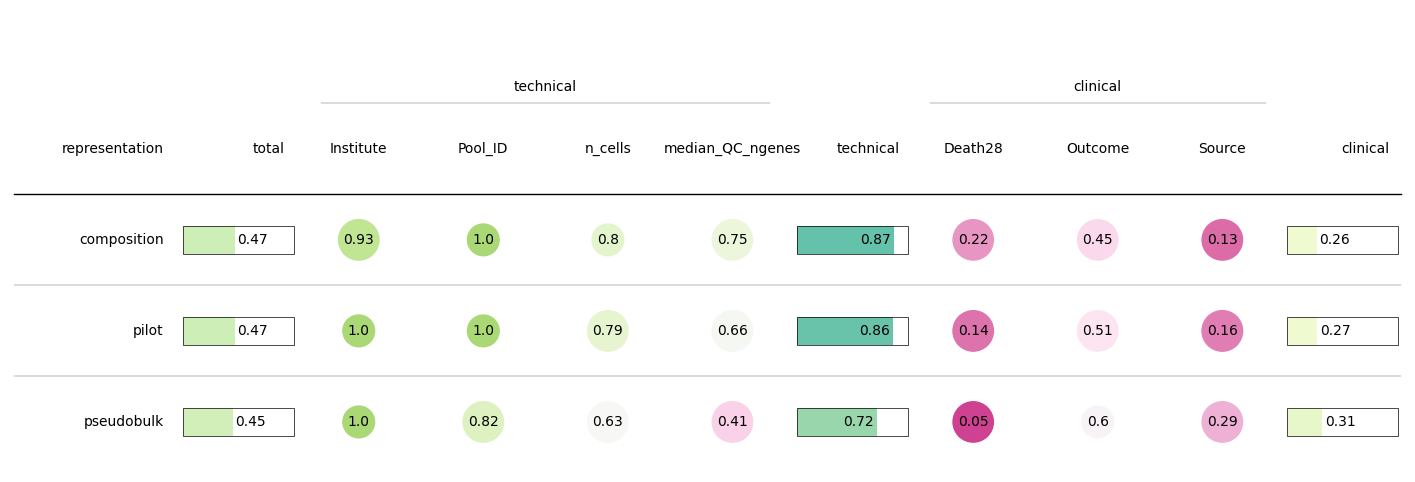

In [ ]:
fig, ax = plt.subplots(figsize=(18, 6))

Table(knn_results_wide[cols_order].sort_values("total", ascending=False), column_definitions=tuple(col_defs), ax=ax)

### How to read this table

Every cell is a score in `[0, 1]` where **higher = better**:

- **Clinical** columns (`Outcome`, `Death28`, `Source`): high means a kNN classifier trained on the sample distances recovers the clinical label.
- **Technical** columns (`Institute`, `Pool_ID`, `n_cells`, `median_QC_ngenes`): high means the *opposite* — the score has been inverted so that high indicates the representation does **not** encode the technical artefact.
- **`trajectory`** is the absolute Spearman correlation between diffusion pseudotime (rooted at the healthiest donor) and `Outcome`. High means the order of severity is preserved along the representation's diffusion graph.
- **`total`** is a weighted average that gives more weight to clinical signal than to batch invariance, so the top of the sorted table is the method most useful for downstream clinical analysis on this dataset.

The `random` baseline is the floor: any real method should beat it on clinical and trajectory columns. If a method *doesn't* beat random there, the method or its hyperparameters need work for this dataset.


# Other methods and tutorials

We covered Pseudobulk, GroupedPseudobulk, CellGroupComposition, PILOT, MOFA, MrVI, and a RandomVector baseline. `patpy` also ships:

- **`patpy.tl.SCPoli`** — conditional VAE that learns a per-sample prototype, batch-aware by construction. Needs `pip install patpy[scpoli]` and (currently) an `anndata < 0.12` env because of how `scarches` imports.
- **`patpy.tl.DiffusionEarthMoverDistance`** — diffusion EMD over composition. Needs `pip install patpy[diffusionemd]` and `scikit-learn < 1.5` for the underlying `DiffusionEMD` package.
- **`patpy.tl.PhEMD`** — pure Python EMD with phenotype trees.
- **`patpy.tl.WassersteinTSNE`** — Wasserstein distances + t-SNE on top.
- **`patpy.tl.GloScope`** / **`patpy.tl.GloScope_py`** — distribution distances over latent space (R-based or pure Python). The R version is the canonical implementation.

Related tutorials:

- [`representation_methods_example.ipynb`](./representation_methods_example.ipynb) — another walkthrough of representation methods on COMBAT.
- [`sources_of_variation_with_gloscope.ipynb`](./sources_of_variation_with_gloscope.ipynb) — deep-dive on GloScope, including the R setup.
- [`supervised_methods_example.ipynb`](./supervised_methods_example.ipynb) — supervised counterparts (MixMIL, PULSAR, PaSCient).
- [`differential_analysis.ipynb`](./differential_analysis.ipynb) — once you have a representation, where to go next.

In the [SPARE benchmark](https://github.com/lueckenlab/SPARE/tree/feature/viash_nextflow_pipeline), GloScope was the best performer overall. The conda env file at [`envs/gloscope.yaml`](https://github.com/lueckenlab/patpy/blob/main/envs/gloscope.yaml) is the simplest way to set up its R dependencies.
